In [1]:
!pip install ultralytics scikit-learn pandas -q

In [2]:
!pip install iterative-stratification

In [3]:
import os
import numpy as np
from collections import Counter
import random
import torch
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import zipfile
import matplotlib.pyplot as plt
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import shutil
from datetime import datetime
from collections import Counter
from tqdm import tqdm
import shutil
from glob import glob
import albumentations as A
import pandas as pd
import zipfile
from pathlib import Path
from google.colab import files

In [5]:

ZIP_NAME = "2026-cv-competition.zip"
EXTRACT_DIR_NAME = "2026-cv-competition"   # папка, куда распакуем

# Возможные пути, где может лежать архив
possible_zip_paths = [
    Path("/content") / ZIP_NAME,              # Colab, если архив в /content/
    Path.cwd() / ZIP_NAME,                   # текущая папка (локально или Colab)
    Path.cwd().parent / ZIP_NAME,            # родительская папка
    Path("/kaggle/working") / ZIP_NAME,      # Kaggle working
    Path("/kaggle/input") / ZIP_NAME,        # Kaggle input (если просто файл)
]

# Дополнительно: рекурсивный поиск в /kaggle/input (если архив внутри подпапки)
if Path("/kaggle/input").exists():
    for p in Path("/kaggle/input").rglob(ZIP_NAME):
        possible_zip_paths.append(p)

zip_path = None
for p in possible_zip_paths:
    if p.exists():
        zip_path = p
        break

if zip_path is None:
    raise FileNotFoundError(
        f"Архив {ZIP_NAME} не найден. Убедитесь, что он находится в корневой директории "
        "(например, /content/ или рядом с ноутбуком)."
    )

print(f"✅ Архив найден: {zip_path}")


# 2. Распаковка (с очисткой, если уже распаковано)


if zip_path.parent == Path("/content"):
    # Если архив в /content/, распаковываем в /content/2026-cv-competition
    extract_root = Path("/content") / EXTRACT_DIR_NAME
else:
    # Иначе распаковываем в ту же папку, где лежит архив
    extract_root = zip_path.parent / EXTRACT_DIR_NAME

# Если папка уже существует, удаляем её для чистой распаковки
if extract_root.exists():
    import shutil
    shutil.rmtree(extract_root)

extract_root.mkdir(parents=True, exist_ok=True)

print(f"Распаковка в {extract_root} ...")
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_root)
print("✅ Распаковка завершена")


# 3. Задаём переменные для работы с данными

BASE = extract_root
X_train_full = BASE / "train" / "train" / "images"
y_train_full = BASE / "train" / "train" / "labels"
X_test = BASE / "test" / "test" / "images"
SAMPLE_SUB_PATH = BASE / "sample_submission.csv"

# Проверка, что всё на месте
assert X_train_full.exists(), f"Не найдена папка {X_train_full}"
assert y_train_full.exists(), f"Не найдена папка {y_train_full}"
assert X_test.exists(), f"Не найдена папка {X_test}"
assert SAMPLE_SUB_PATH.exists(), f"Не найден {SAMPLE_SUB_PATH}"

print(f"✅ Все пути определены:\n   BASE = {BASE}\n   X_train_full = {X_train_full}\n   ...")

✅ Архив найден: /content/2026-cv-competition.zip
Распаковка в /content/2026-cv-competition ...
✅ Распаковка завершена
✅ Все пути определены:
   BASE = /content/2026-cv-competition
   X_train_full = /content/2026-cv-competition/train/train/images
   ...


Посмотрим на сами данные

In [6]:

BASE = "/content/2026-cv-competition"

# Правильные пути (с учётом вложенности)
X_train_full = f"{BASE}/train/train/images"
y_train_full = f"{BASE}/train/train/labels"
X_test = f"{BASE}/test/test/images"

# Проверяем
print("Изображения:", os.path.exists(X_train_full))
print("Разметка:", os.path.exists(y_train_full))
print("Тест:", os.path.exists(X_test))

# Сколько файлов
print(f"\nФото в train: {len(os.listdir(X_train_full))}")
print(f"Разметок в train: {len(os.listdir(y_train_full))}")

Изображения: True
Разметка: True
Тест: True

Фото в train: 1697
Разметок в train: 1697


проверим на наличие редких классов (их нет и это радует )

In [7]:

all_classes = []
class_counts = Counter()

for label_file in os.listdir(y_train_full):
    with open(f"{y_train_full}/{label_file}", 'r') as f:
        for line in f:
            cls = int(line.split()[0])
            all_classes.append(cls)
            class_counts[cls] += 1

print(f"Всего классов: {len(class_counts)} (из 52)")
print(f"Всего объектов: {len(all_classes)}")
print(f"Среднее объектов на класс: {np.mean(list(class_counts.values())):.1f}")
print(f"Медиана: {np.median(list(class_counts.values())):.1f}")
print(f"Максимум: {max(class_counts.values())}")
print(f"Минимум: {min(class_counts.values())}")

rare_classes = [c for c, cnt in class_counts.items() if cnt < 10]
print(f"\nРедких классов (<10 объектов): {len(rare_classes)}")
if rare_classes:
    print(f"Примеры: {rare_classes[:10]}")

Всего классов: 52 (из 52)
Всего объектов: 10498
Среднее объектов на класс: 201.9
Медиана: 178.0
Максимум: 853
Минимум: 83

Редких классов (<10 объектов): 0


посмотрим на размеры обьяектов

In [8]:

areas = []

for label_file in list(os.listdir(y_train_full))[:200]:
    with open(f"{y_train_full}/{label_file}", 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) == 5:
                w = float(parts[3])
                h = float(parts[4])
                areas.append(w * h)

if areas:
    print(f"Средняя площадь объекта: {np.mean(areas):.4f}")
    print(f"Медианная площадь: {np.median(areas):.4f}")

    small = sum(1 for a in areas if a < 0.01)
    medium = sum(1 for a in areas if 0.01 <= a < 0.05)
    large = sum(1 for a in areas if a >= 0.05)

    print(f"\nМелкие (<1%): {small/len(areas)*100:.1f}%")
    print(f"Средние (1-5%): {medium/len(areas)*100:.1f}%")
    print(f"Крупные (>5%): {large/len(areas)*100:.1f}%")

Средняя площадь объекта: 0.0525
Медианная площадь: 0.0315

Мелкие (<1%): 18.4%
Средние (1-5%): 49.3%
Крупные (>5%): 32.2%


фиксируем seed

In [9]:
SEED = 993

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


разбиваем на трейн и валидацию, для сохранение распределения каждого класса использую MultilabelStratifiedKFold

In [10]:

all_images = [f for f in os.listdir(X_train_full) if f.endswith(('.jpg', '.png', '.jpeg'))]

image_ids = []
label_matrix = []

for img in all_images:
    label_file = img.replace('.jpg', '.txt').replace('.png', '.txt')
    label_path = os.path.join(y_train_full, label_file)

    present = [0]*52
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls = int(parts[0])
                    if 0 <= cls < 52:
                        present[cls] = 1
    image_ids.append(img)
    label_matrix.append(present)

label_matrix = np.array(label_matrix)


mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=993)

for fold, (train_idx, val_idx) in enumerate(mskf.split(image_ids, label_matrix)):
    if fold == 0:
        train_imgs = [image_ids[i] for i in train_idx]
        val_imgs   = [image_ids[i] for i in val_idx]
        break

print(f"Train: {len(train_imgs)}, Val: {len(val_imgs)}")
print("Распределение классов в train и val (средняя частота):")
# Проверка баланса
train_counts = label_matrix[train_idx].sum(axis=0)
val_counts   = label_matrix[val_idx].sum(axis=0)
for c in range(52):
    if train_counts[c] + val_counts[c] > 0:
        print(f"Class {c:2d}: train={train_counts[c]:4d} val={val_counts[c]:4d} "
              f"ratio={train_counts[c]/(train_counts[c]+val_counts[c]):.2f}")

Train: 1353, Val: 344
Распределение классов в train и val (средняя частота):
Class  0: train= 116 val=  28 ratio=0.81
Class  1: train=  76 val=  19 ratio=0.80
Class  2: train= 118 val=  30 ratio=0.80
Class  3: train= 113 val=  28 ratio=0.80
Class  4: train= 108 val=  24 ratio=0.82
Class  5: train= 103 val=  23 ratio=0.82
Class  6: train= 131 val=  33 ratio=0.80
Class  7: train= 149 val=  36 ratio=0.81
Class  8: train= 111 val=  28 ratio=0.80
Class  9: train= 143 val=  33 ratio=0.81
Class 10: train= 165 val=  38 ratio=0.81
Class 11: train= 117 val=  29 ratio=0.80
Class 12: train= 132 val=  26 ratio=0.84
Class 13: train= 158 val=  39 ratio=0.80
Class 14: train= 148 val=  38 ratio=0.80
Class 15: train=  65 val=  17 ratio=0.79
Class 16: train=  90 val=  23 ratio=0.80
Class 17: train= 127 val=  34 ratio=0.79
Class 18: train= 130 val=  32 ratio=0.80
Class 19: train= 147 val=  36 ratio=0.80
Class 20: train= 138 val=  35 ratio=0.80
Class 21: train= 143 val=  35 ratio=0.80
Class 22: train= 166 

Создание символических ссылок для того, чтобы не дублировать файлы (изображения и разметку), но при этом предоставить модели чёткую структуру папок для обучения и валидации.

In [11]:
# Создаём папки
os.makedirs(f"{BASE}/train_split/images", exist_ok=True)
os.makedirs(f"{BASE}/train_split/labels", exist_ok=True)
os.makedirs(f"{BASE}/val_split/images", exist_ok=True)
os.makedirs(f"{BASE}/val_split/labels", exist_ok=True)

# Ссылки для train
for img in train_imgs:
    # Изображение
    os.symlink(f"{X_train_full}/{img}", f"{BASE}/train_split/images/{img}")
    # Разметка
    label = img.replace('.jpg', '.txt').replace('.png', '.txt')
    os.symlink(f"{y_train_full}/{label}", f"{BASE}/train_split/labels/{label}")

# Ссылки для val
for img in val_imgs:
    os.symlink(f"{X_train_full}/{img}", f"{BASE}/val_split/images/{img}")
    label = img.replace('.jpg', '.txt').replace('.png', '.txt')
    os.symlink(f"{y_train_full}/{label}", f"{BASE}/val_split/labels/{label}")




Создание data.yaml

In [12]:
yaml_content = f"""
path: {BASE}
train: train_split/images
val: val_split/images
test: {X_test}

nc: 52
names: {[str(i) for i in range(52)]}
"""

with open(f"{BASE}/data.yaml", "w") as f:
    f.write(yaml_content)


обучаем YOLO 26 s с подобранными аугментациями

In [13]:

DATA_YAML = f"{BASE}/data.yaml"


custom_aug = A.Compose([
    # Геометрические
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.25),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.15,
        rotate_limit=20,
        border_mode=0,
        p=0.5
    ),
    # Цвет / яркость / контраст
    A.RandomBrightnessContrast(
        brightness_limit=0.3,
        contrast_limit=0.3,
        p=0.6
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20,
        val_shift_limit=15,
        p=0.4
    ),
    # Артефакты сжатия JPEG (ИСПРАВЛЕНО)
    A.ImageCompression(
        quality_range=(40, 100),
        p=0.4
    ),
    # Симуляция «чёрных полос» и окклюзий (ИСПРАВЛЕНО)
    A.CoarseDropout(
        num_holes_range=(2, 8),
        hole_height_range=(8, 32),
        hole_width_range=(8, 32),
        fill=0,
        p=0.3
    ),
    # Шумы
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),
    A.SaltAndPepper(amount=(0.01, 0.03), p=0.2),
    A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.3),
    # Размытия
    A.MotionBlur(blur_limit=5, p=0.2),
    A.GaussianBlur(blur_limit=(3,7), p=0.2),
    # Атмосферные эффекты
    A.RandomFog(fog_coef_lower=0.3, fog_coef_upper=0.8, p=0.15),
    A.CLAHE(p=0.2),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3))


model = YOLO('yolo26s.pt')


model.train(
    data=DATA_YAML,
    epochs=35,             # можно увеличить до 40–50, так как аугментации сильные
    imgsz=640,
    batch=8,
    workers=4,
    device=device,
    seed=933,
    warmup_epochs=5,
    warmup_bias_lr=0.1,
    warmup_momentum=0.8,
    optimizer='AdamW',
    lr0=0.001,
    weight_decay=0.0005,
    cos_lr=True,
    lrf=0.01,
    patience=6,
    augmentations=custom_aug,
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0, perspective=0.0,
    fliplr=0.0, flipud=0.0,
    mosaic=0.0, mixup=0.0, copy_paste=0.0,
    verbose=True,
    plots=True
)





/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_6093/3942100063.py:42: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),
/tmp/ipykernel_6093/3942100063.py:49: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.3, fog_coef_upper=0.8, p=0.15),


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=Compose([
  HorizontalFlip(p=0.5),
  VerticalFlip(p=0.25),
  RandomRotate90(p=0.5),
  ShiftScaleRotate(p=0.5, shift_limit_x=(-0.05, 0.05), shift_limit_y=(-0.05, 0.05), scale_limit=(-0.15000000000000002, 0.1499999999999999), rotate_limit=(-20.0, 20.0), interpolation=1, border_mode=0, fill=0.0, fill_mask=0.0, rotate_method='largest_box', mask_interpolation=0),
  RandomBrightnessContrast(p=0.6, brightness_by_max=True, brightness_limit=(-0.3, 0.3), contrast_limit=(-0.3, 0.3), ensure_safe_range=False),
  HueSaturationValue(p=0.4, hue_shift_limit=(-10.0, 10.0), sat_shift_limit=(-20.0, 20.0), val_shift_limit=(-15.0, 15.0)),
  ImageCompression(p=0.4, compression_type='jpeg', quality_range=(40, 100)),
  CoarseDropout(p=0.3, fill=0.0, fill_mask=None, hole_height_range=(8, 32), hole_width_range=(8, 32), num_holes_range=(2, 8)),
  GaussNoise(p=0.4, mean_range=(0.0, 0.0), noise_scale_factor=1.0, per_channel=True, 

/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:465: UserWarning: transforms is single transform, but a sequence is expected! Transform will be wrapped into list.
  super().__init__(


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 944.2±567.2 MB/s, size: 56.5 KB)
val: Scanning /content/2026-cv-competition/val_split/labels... 344 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 344/344 1.5Kit/s 0.2s
val: New cache created: /content/2026-cv-competition/val_split/labels.cache
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0005), 126 bias(decay=0.0)
Plotting labels to /content/runs/detect/train/labels.jpg... 
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /content/runs/detect/train
Starting training for 35 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/35      2.63G      1.684      4.618    0.01998         12        640: 100% ━━━━━━━━━━━━ 170/170 1.1it/s 2:38
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 2.0it/s 11.2s
                   all        344       2

/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:465: UserWarning: transforms is single transform, but a sequence is expected! Transform will be wrapped into list.
  super().__init__(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      26/35      3.03G      1.178      0.821    0.01279          6        640: 100% ━━━━━━━━━━━━ 170/170 1.2it/s 2:17
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 4.6it/s 4.7s
                   all        344       2088      0.793      0.802      0.805      0.529

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      27/35      3.03G      1.173     0.8326    0.01296          1        640: 100% ━━━━━━━━━━━━ 170/170 1.4it/s 2:04
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 4.0it/s 5.5s
                   all        344       2088      0.794      0.799      0.801      0.533

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      28/35      3.03G      1.163     0.7942    0.01262          7        640: 100% ━━━━━━━━━━━

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bcdfca4a8a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.03303

путь к весам модели

In [14]:
PATH_V26s_aug_hard =  '/content/runs/detect/train/weights/best.pt'

строим графики

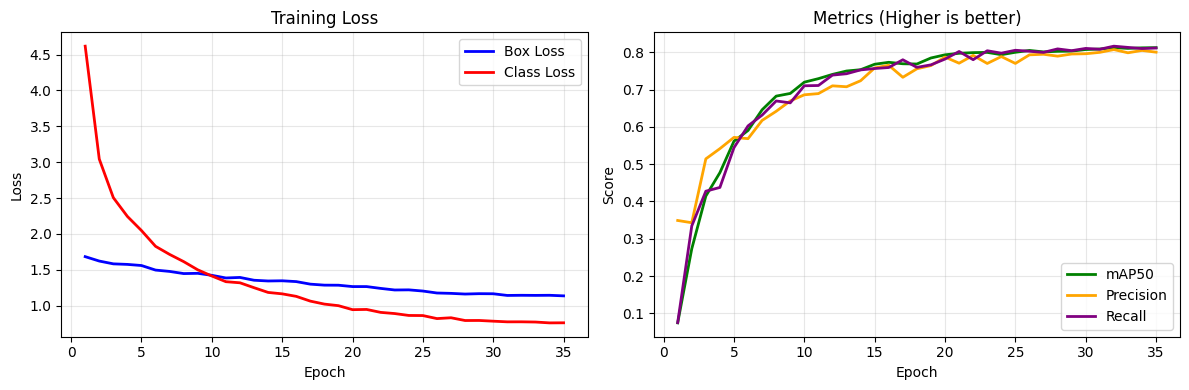

ЛУЧШИЕ РЕЗУЛЬТАТЫ:
Лучший mAP50: 0.8122 (эпоха 32)
Лучший Precision: 0.8070
Лучший Recall: 0.8161


In [15]:

results_df = pd.read_csv('/content/runs/detect/train/results.csv')

epochs = range(1, len(results_df) + 1)

plt.figure(figsize=(12, 4))

# График 1: Потери (аналог train_loss)
plt.subplot(1, 2, 1)
plt.plot(epochs, results_df['train/box_loss'], 'b-', linewidth=2, label='Box Loss')
plt.plot(epochs, results_df['train/cls_loss'], 'r-', linewidth=2, label='Class Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Точность (аналог accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs, results_df['metrics/mAP50(B)'], 'g-', linewidth=2, label='mAP50')
plt.plot(epochs, results_df['metrics/precision(B)'], 'orange', linewidth=2, label='Precision')
plt.plot(epochs, results_df['metrics/recall(B)'], 'purple', linewidth=2, label='Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Metrics (Higher is better)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ЛУЧШИЕ РЕЗУЛЬТАТЫ:")
print("="*50)
print(f"Лучший mAP50: {results_df['metrics/mAP50(B)'].max():.4f} (эпоха {results_df['metrics/mAP50(B)'].idxmax() + 1})")
print(f"Лучший Precision: {results_df['metrics/precision(B)'].max():.4f}")
print(f"Лучший Recall: {results_df['metrics/recall(B)'].max():.4f}")

тест модели и оформление ответов для кагла

In [16]:


BASE = "/content/2026-cv-competition"
X_test = f"{BASE}/test/test/images"
PATH_V= PATH_V26s_aug_hard
SAMPLE_SUB_PATH = f"{BASE}/sample_submission.csv"

template = pd.read_csv(SAMPLE_SUB_PATH)
best_model = YOLO(PATH_V)

test_files = sorted(
    f for f in os.listdir(X_test)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
)

# basename -> actual filename
file_map = {os.path.splitext(f)[0]: f for f in test_files}

predictions = []

for image_id in template["image_id"]:
    img_file = file_map.get(image_id)

    if img_file is None:
        predictions.append(" ")
        continue

    img_path = os.path.join(X_test, img_file)
    results = best_model.predict(img_path,conf=0.001, verbose=False)
    r = results[0]

    parts = []

    if r.boxes is not None and len(r.boxes) > 0:
        boxes = r.boxes.xyxy.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy()
        scores = r.boxes.conf.cpu().numpy()

        for cls, score, box in zip(classes, scores, boxes):
            x1, y1, x2, y2 = map(int, box)

            if x2 <= x1 or y2 <= y1:
                continue

            # 6 токенов: class score x1 y1 x2 y2
            parts.append(f"{int(cls)} {float(score):.6f} {x1} {y1} {x2} {y2}")

    pred_string = " ".join(parts).strip()
    if pred_string == "":
        pred_string = " "

    predictions.append(pred_string)

submission = template.copy()
submission["PredictionString"] = predictions

print("Всего строк:", len(submission))
print("NaN в PredictionString:", submission["PredictionString"].isna().sum())
print("Непустых предсказаний:", (submission["PredictionString"].str.strip() != "").sum())

# проверка уже под 6 токенов
bad_rows = []
for idx, s in enumerate(submission["PredictionString"], start=1):
    tokens = str(s).strip().split()
    if len(tokens) != 0 and len(tokens) % 6 != 0:
        bad_rows.append((idx, len(tokens), s))

print("Строк с битым форматом:", len(bad_rows))
if bad_rows:
    print("Первая битая строка:", bad_rows[0])

output_path = "/content/submission_fixed11_0001conf_final.csv"
submission.to_csv(output_path, index=False)

print("Сохранено:", output_path)
print(submission.head())

Всего строк: 424
NaN в PredictionString: 0
Непустых предсказаний: 424
Строк с битым форматом: 0
Сохранено: /content/submission_fixed6.csv
                                            image_id  \
0  IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1a...   
1  IMG20240228122949_jpg.rf.f763b523e7bb4e7250796...   
2  IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34...   
3  IMG20240228123115_jpg.rf.3b9ae83d0bc7242bafe52...   
4  IMG20240228123131_jpg.rf.84cf43cf1c7a8d09dc507...   

                                    PredictionString  
0  28 0.907657 170 545 275 610 44 0.849542 387 43...  
1  4 0.072483 48 119 361 351 11 0.065936 512 131 ...  
2  43 0.837313 457 291 543 426 30 0.573086 139 22...  
3  43 0.834143 420 337 492 413 4 0.754625 182 434...  
4  0 0.828265 460 3 543 159 43 0.770460 454 189 5...  


скачиваем итоговый файл с ответами

In [17]:

files.download(output_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Я выбрала порог 0.001, хотя он достаточно экстремальный, я все же остановилась на нем, так как он дал лучный результат на открытой части соревнования. Также я заглянула в тест и заметила что он отличается от трейна, он сложнее, многие фотографии в плохом качестве есть шумы и вероятно были наложены фильтры, в результате чего уверенность модели на предсказании довольно низкая. Чтобы не терять потенциально верные ответы модели я взяла порог по ниже.